# `rev_tortuosity`

The algorithm uses `tortuosity_bt` to determine the tortuosity of an image in all three directions at various different block sizes, incorporating parallelized processing.



In [ ]:
import porespy as ps
import numpy as np
import matplotlib.pyplot as plt

ps.settings.loglevel=50

Generate an artificial 2D image for illustration purposes:

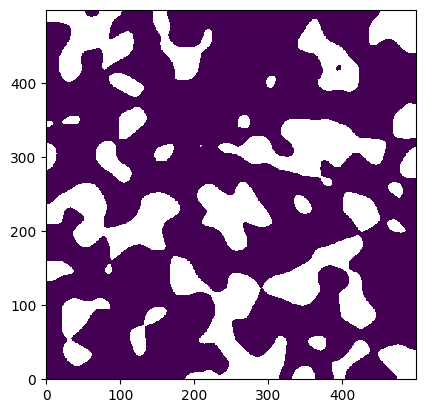

In [ ]:
im = ps.generators.blobs([500]*2, seed=1, porosity=0.7)
ps.imshow(im);

`im`

This parameter accepts the image for analysis as an ndarray. Can be either 2D or 3D.

`block_sizes`

This parameter allows the user to determine the sizes of the blocks to be analyzed. If left empty, the block sizes will be determined automatically. Alternatively, the array of block sizes can be obtained using `get_block_sizes`, finding valid block sizes for the given image.

`use_dask`

This parameter is enabled by default, and allows the use of dask for parallelized computing, allowing the computations to be completed faster given more computing cores.

In [3]:
block_sizes = ps.beta.get_block_sizes(im, [50,100])
df = ps.beta.rev_tortuosity(im, block_sizes)

Analyzing block size of 50:
[########################################] | 100% Completed | 6.06 ss
Analyzing block size of 55:
[########################################] | 100% Completed | 4.39 sms
Analyzing block size of 62:
[########################################] | 100% Completed | 3.83 sms
Analyzing block size of 71:
[########################################] | 100% Completed | 3.33 sms
Analyzing block size of 83:
[########################################] | 100% Completed | 2.62 sms
Analyzing block size of 100:
[########################################] | 100% Completed | 2.32 sms


`rev_plot`

A companion function, `rev_plot` allows for the easy plotting of the final result of `rev_tortuosity`. The first parameter `df` is the output from `rev_tortuosity`, and `size` is the length of one side of the cubic / square image. `figsize` is the size of the figure outputted by `matplotlib.pyplot`.

The output is a violin plot, showing the frequency of the tortuosity at the given block sizing.

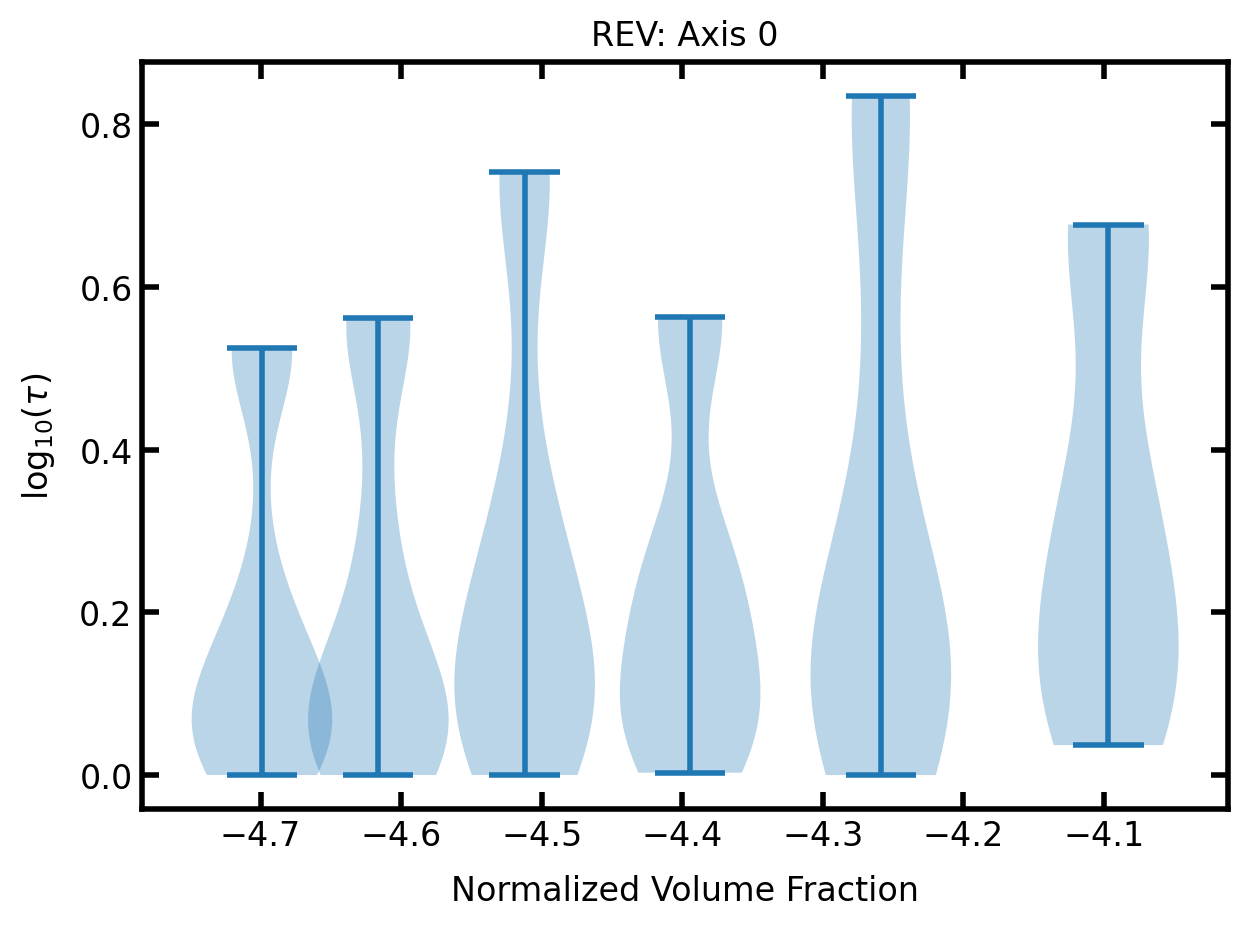

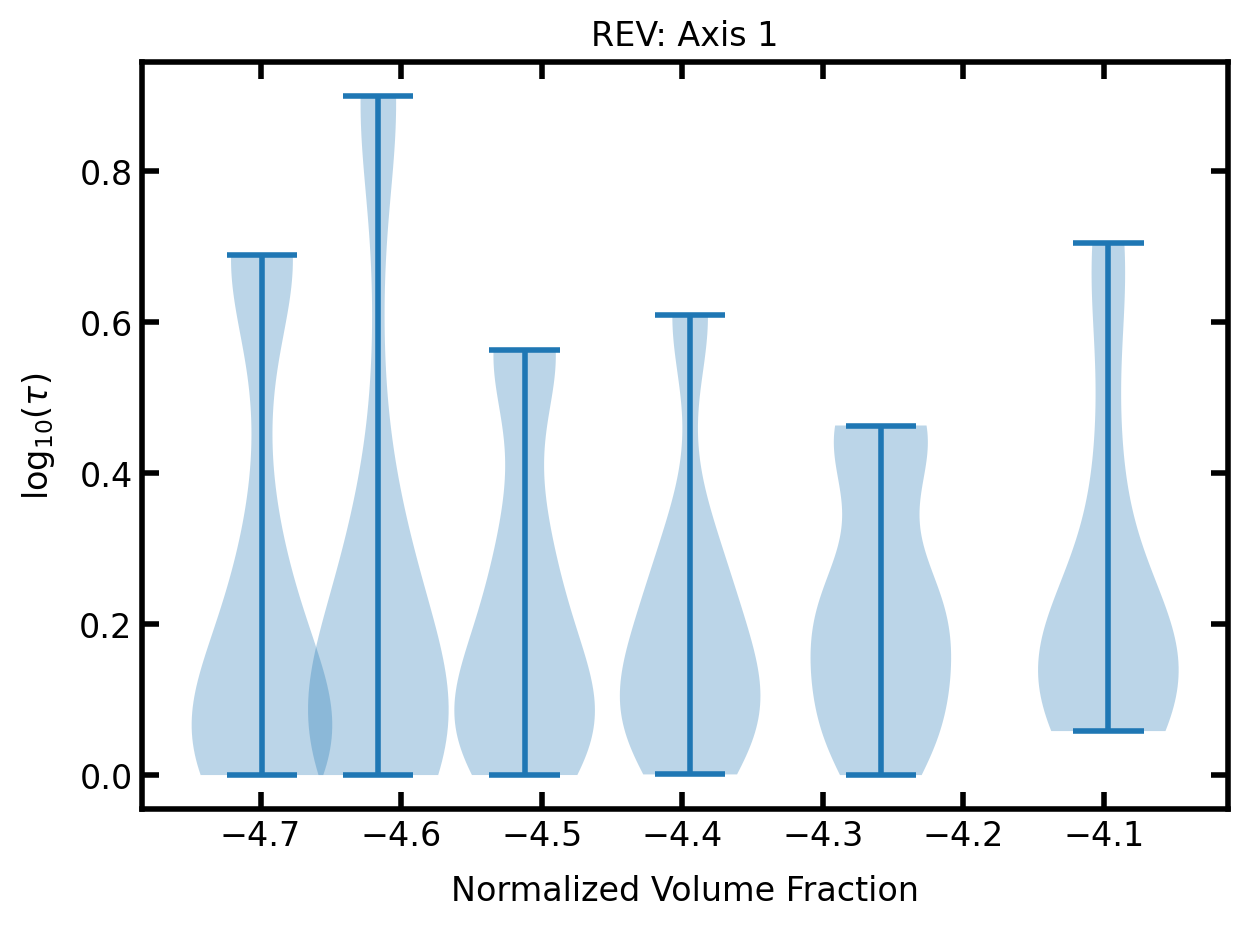

In [18]:
fig, ax = ps.beta.rev_plot(df, 500, [6.4,4.8])

The results show the tortuosity distribution for the specified block sizes. This can be compared to the ground truth by using `tortuosity_fd`.

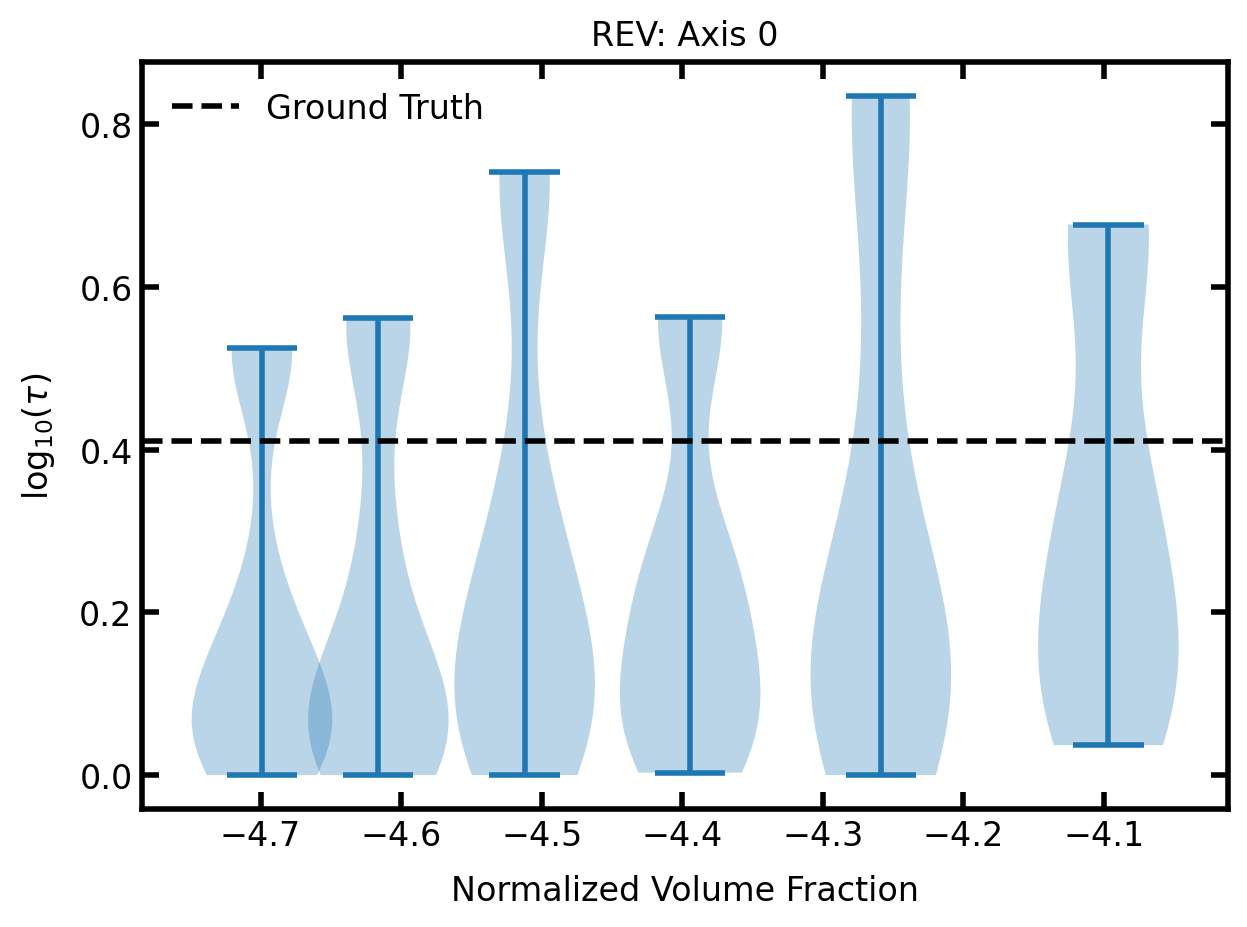

In [19]:
ground_truth = ps.simulations.tortuosity_fd(im, 0)
plt.sca(ax[0])
plt.axhline(np.log10(ground_truth.tortuosity), linestyle='--', color='k', label="Ground Truth")
plt.legend()
plt.show()

From the plots, as the block sizes increase (and the volume fraction per block increases), the tortuosity values begin to converge on the ground truth of the whole image.